1) find threhsold
2) check how many in test set are to be edited if applying threshold
3) save final test set for each task that need to be edited after applying threshold (i.e. energy model class proba is lower than threshold)

In [4]:
import os
os.chdir('/data/hyeryung/mucoco')
import argparse
import math
import json

import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score
import seaborn as sns
import numpy as np
from transformers import AutoTokenizer, AutoConfig
import transformers


import new_module.losses as lossbuilder
from new_module.utils.robertacustom import RobertaCustomForSequenceClassification
from new_module.em_training.analyze_model import predict_labels

def bin_labels(x):
    if 0 <= x < 0.1:
        return 0
    elif 0.1 <= x < 0.2:
        return 1
    elif 0.2 <= x < 0.3:
        return 2
    elif 0.3 <= x < 0.4:
        return 3
    elif 0.4 <= x < 0.5:
        return 4
    elif 0.5 <= x < 0.6:
        return 5
    elif 0.6 <= x < 0.7:
        return 6
    elif 0.7 <= x < 0.8:
        return 7
    elif 0.8 <= x < 0.9:
        return 8
    elif 0.9 <= x <= 1.0:
        return 9


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Finding threshold

## toxicity, energy

In [ ]:
args = argparse.Namespace(
    checkpoint_dir='/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-energy-training/step_1000_best_checkpoint',
    test_data_path='/data/hyeryung/loc_edit/data/toxicity/jigsaw-unintended-bias-in-toxicity-classification/fine-grained/valid.jsonl',
    test_data_type='jsonl',
    output_dir='/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-energy-training/step_1000_best_checkpoint',
    batch_size=32,
    model_type='roberta-base'
)
label_predictions = predict_labels(args,device)
print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")


In [19]:
label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.051385
0.20    0.153811
0.25    0.212688
0.30    0.278912
0.40    0.420506
0.50    0.584498
0.60    0.754991
0.70    0.877541
0.75    0.911311
0.80    0.932461
0.90    0.962967
1.00    0.996601
Name: predictions, dtype: float64

In [ ]:
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")

acc: 0.8270
auroc: 0.9199


In [ ]:
print(f"Proportion of label 0: {(label_predictions['labels'] <= 0.5).sum() / len(label_predictions['labels'])}")
print(label_predictions['predictions'].quantile(0.5))

Proportion of label 0: 0.5027932960893855
0.584498405456543


### plots

Text(0.5, 1.0, 'Energy Model Predictions Sorted by Value (toxicity)')

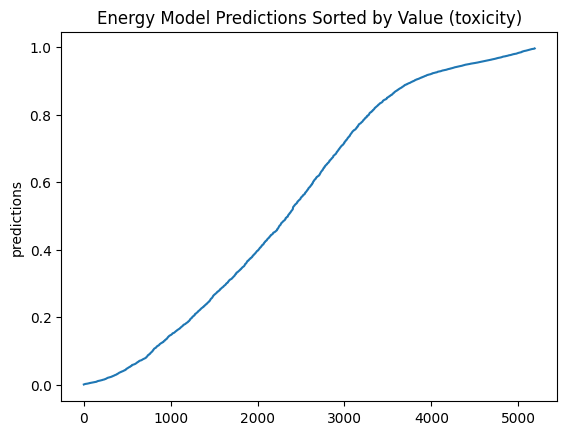

In [ ]:
sorted_vals = label_predictions['predictions'].sort_values()
sns.lineplot(data = None, x= range(len(sorted_vals)), y =sorted_vals)
plt.title('Energy Model Predictions Sorted by Value (toxicity)')

<Axes: xlabel='labels', ylabel='predictions'>

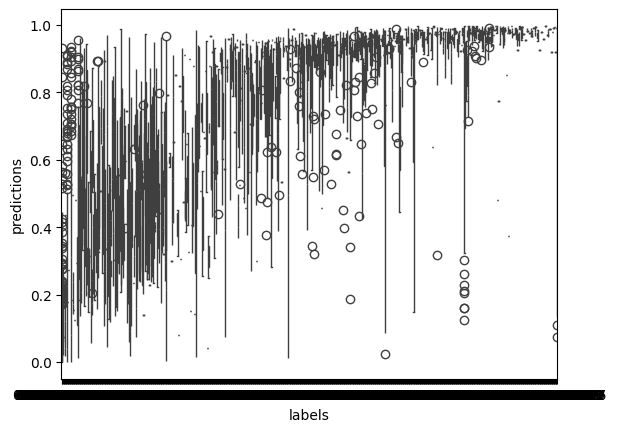

In [ ]:
sns.boxplot(data=label_predictions, x='labels', y='predictions')

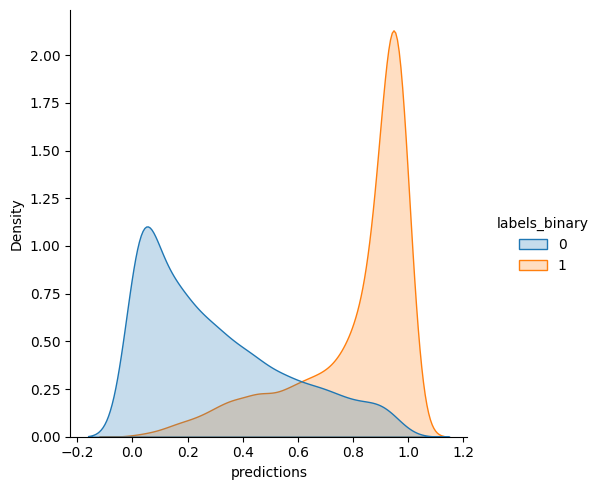

In [ ]:
label_predictions['labels_binary'] = label_predictions['labels'].apply(lambda x: 1 if x > 0.5 else 0)
sns.displot(label_predictions, x='predictions', hue='labels_binary', kind='kde', fill=True)

### balanced valid set

In [128]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-energy-training/step_1000_best_checkpoint/labels_predictions.csv', index_col=0)

In [ ]:
label_predictions['labels'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]) ## already balanced!

0.10    0.111111
0.20    0.200000
0.25    0.300000
0.30    0.333333
0.40    0.400000
0.50    0.500000
0.60    0.700000
0.70    0.764706
0.75    0.800000
0.80    0.848101
0.90    0.957447
1.00    1.000000
Name: labels, dtype: float64

### nontoxicity threshold

In [21]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-energy-training/step_1000_best_checkpoint/labels_predictions.csv', index_col=0)

In [22]:
label_predictions['predictions'] = 1 - label_predictions['predictions']

In [23]:
label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]) ## already balanced!

0.10    0.037033
0.20    0.067539
0.25    0.088689
0.30    0.122459
0.40    0.245009
0.50    0.415502
0.60    0.579494
0.70    0.721088
0.75    0.787312
0.80    0.846189
0.90    0.948615
1.00    0.999540
Name: predictions, dtype: float64

## toxicity, classifier

In [ ]:
args = argparse.Namespace(
    checkpoint_dir='/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-with-gpt2-large-embeds-2/step_2600_best_checkpoint/',
    test_data_path='/data/hyeryung/loc_edit/data/toxicity/jigsaw-unintended-bias-in-toxicity-classification/fine-grained/valid.jsonl',
    test_data_type='jsonl',
    output_dir='/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-with-gpt2-large-embeds-2/step_2600_best_checkpoint/',
    batch_size=32,
    model_type='roberta-base-custom'
)

label_predictions = predict_labels(args,device)
print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")


50265


In [21]:
label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.005478
0.20    0.035349
0.25    0.066514
0.30    0.126741
0.40    0.333116
0.50    0.624835
0.60    0.880091
0.70    0.987265
0.75    0.996154
0.80    0.998923
0.90    0.999896
1.00    0.999940
Name: predictions, dtype: float64

In [ ]:
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")

acc: 0.8154
auroc: 0.9055


### nontoxicity threshold

In [51]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-with-gpt2-large-embeds-2/step_2600_best_checkpoint/labels_predictions.csv', index_col=0)

In [52]:
label_predictions['predictions'] = 1 - label_predictions['predictions']

In [53]:
label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]) ## already balanced!

0.10    0.000104
0.20    0.001077
0.25    0.003846
0.30    0.012735
0.40    0.119909
0.50    0.375165
0.60    0.666884
0.70    0.873259
0.75    0.933486
0.80    0.964651
0.90    0.994522
1.00    0.999640
Name: predictions, dtype: float64

## formality, energy

In [ ]:
# formality, energy model
args = argparse.Namespace(
    checkpoint_dir='/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-energy-training/step_1120_best_checkpoint/',
    test_data_path='/data/hyeryung/loc_edit/data/formality/PT16/valid.tsv',
    test_data_type='tsv',
    output_dir='/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-energy-training/step_1120_best_checkpoint/',
    batch_size=32,
    model_type='roberta-base'
)

label_predictions = predict_labels(args,device)
print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")


0.10    0.016616
0.20    0.058802
0.25    0.091474
0.30    0.117134
0.40    0.257464
0.50    0.364168
0.60    0.461556
0.70    0.539999
0.75    0.586064
0.80    0.640245
0.90    0.794336
1.00    0.985254
Name: predictions, dtype: float64
acc: 0.8431
auroc: 0.9090


In [ ]:
prop_75 = (label_predictions['labels'] <= 0.75).sum() / len(label_predictions['labels'])
print(f"Proportion of label 0: {prop_75}")
print(label_predictions['predictions'].quantile(prop_75))

Proportion of label 0: 0.9255533199195171
0.849987830194669


### plots

Text(0.5, 1.0, 'Energy Model Predictions Sorted by Value (formality)')

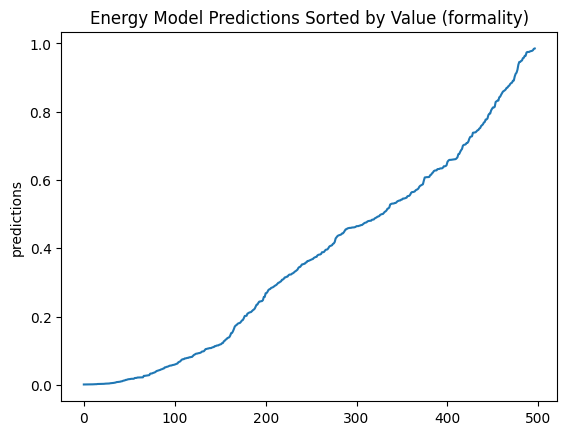

In [116]:
sorted_vals = label_predictions['predictions'].sort_values()
sns.lineplot(data = None, x= range(len(sorted_vals)), y =sorted_vals)
plt.title('Energy Model Predictions Sorted by Value (formality)')

<Axes: xlabel='labels', ylabel='predictions'>

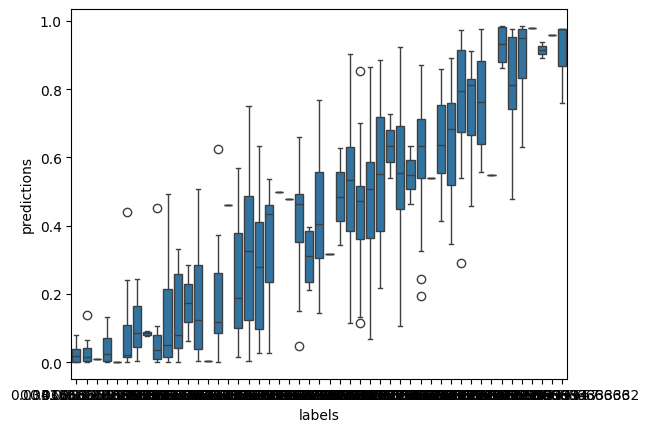

In [104]:
sns.boxplot(data=label_predictions, x='labels', y='predictions')

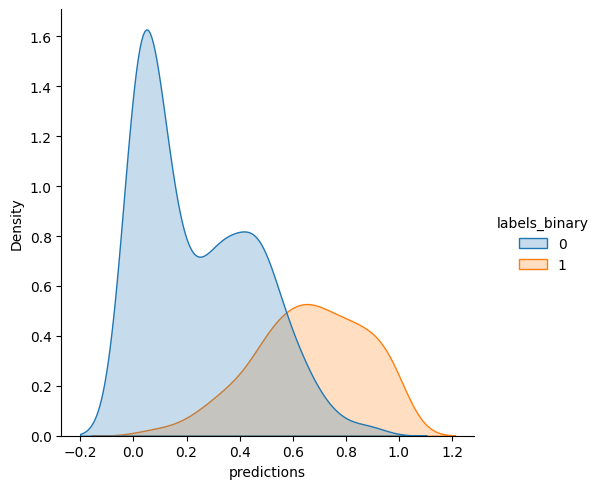

In [107]:
label_predictions['labels_binary'] = label_predictions['labels'].apply(lambda x: 1 if x > 0.5 else 0)
sns.displot(label_predictions, x='predictions', hue='labels_binary', kind='kde', fill=True)

### balanced valid set

In [ ]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-energy-training/step_1120_best_checkpoint/labels_predictions.csv', index_col=0)

In [ ]:
label_predictions['labels'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.100000
0.20    0.166667
0.25    0.208333
0.30    0.233333
0.40    0.300000
0.50    0.366667
0.60    0.452778
0.70    0.533333
0.75    0.566667
0.80    0.600000
0.90    0.700000
1.00    0.933333
Name: labels, dtype: float64

In [ ]:


label_predictions['labels_bins'] = label_predictions['labels'].apply(bin_labels)

In [ ]:
label_predictions['labels_bins'].value_counts().sort_index()

labels_bins
0    40
1    84
2    56
3    91
4    51
5    65
6    54
7    37
8    13
9     6
Name: count, dtype: int64

In [ ]:
balanced_label_predictions = label_predictions.loc[label_predictions['labels_bins'] < 9,:].groupby('labels_bins').sample(13,random_state=999)#.drop_duplicates()
balanced_label_predictions = pd.concat([balanced_label_predictions, label_predictions.loc[label_predictions['labels_bins'] == 9,:]])
print(balanced_label_predictions.shape)

(123, 3)


In [ ]:
balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.027309
0.20    0.092905
0.25    0.116525
0.30    0.151714
0.40    0.284894
0.50    0.461653
0.60    0.545315
0.70    0.650393
0.75    0.739051
0.80    0.808901
0.90    0.933145
1.00    0.985254
Name: predictions, dtype: float64

In [ ]:
print(f"acc: {accuracy_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions']):.4f}")


acc: 0.8537
auroc: 0.9318


### informality threshold

In [29]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-energy-training/step_1120_best_checkpoint/labels_predictions.csv', index_col=0)

In [30]:
label_predictions['labels_bins'] = label_predictions['labels'].apply(bin_labels)

In [31]:
balanced_label_predictions = label_predictions.loc[label_predictions['labels_bins'] < 9,:].groupby('labels_bins').sample(13,random_state=999)#.drop_duplicates()
balanced_label_predictions = pd.concat([balanced_label_predictions, label_predictions.loc[label_predictions['labels_bins'] == 9,:]])
print(balanced_label_predictions.shape)

(123, 3)


In [32]:
balanced_label_predictions['predictions'] = 1 - balanced_label_predictions['predictions']

In [33]:
balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.066855
0.20    0.191099
0.25    0.260949
0.30    0.349607
0.40    0.454685
0.50    0.538347
0.60    0.715106
0.70    0.848286
0.75    0.883475
0.80    0.907095
0.90    0.972691
1.00    0.998873
Name: predictions, dtype: float64

## formality, classifier

In [ ]:
# formality, classifier
args = argparse.Namespace(
    checkpoint_dir='/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-with-gpt2-large-embeds/step_1116_best_checkpoint/',
    test_data_path='/data/hyeryung/loc_edit/data/formality/PT16/valid.tsv',
    test_data_type='tsv',
    output_dir='/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-with-gpt2-large-embeds/step_1116_best_checkpoint/',
    batch_size=32,
    model_type='roberta-base-custom'
)

label_predictions = predict_labels(args,device)
print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")


50265
0.10    0.000124
0.20    0.000126
0.25    0.000128
0.30    0.000129
0.40    0.000134
0.50    0.000216
0.60    0.002563
0.70    0.034903
0.75    0.231531
0.80    0.415012
0.90    0.773593
1.00    0.991355
Name: predictions, dtype: float64
acc: 0.7968
auroc: 0.8404


In [ ]:
print(f"Proportion of label 0: {(label_predictions['labels'] <= 0.5).sum() / len(label_predictions['labels'])}")
print(label_predictions['predictions'].quantile(0.69))

Proportion of label 0: 0.6881287726358148
0.025518970564007648


### plots

Text(0.5, 1.0, 'Classifier Model Predictions Sorted by Value (formality)')

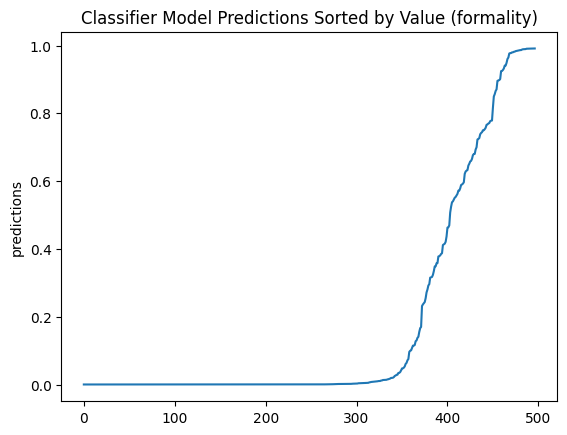

In [113]:
sorted_vals = label_predictions['predictions'].sort_values()
sns.lineplot(data = None, x= range(len(sorted_vals)), y =sorted_vals)
plt.title('Classifier Model Predictions Sorted by Value (formality)')

<Axes: xlabel='labels', ylabel='predictions'>

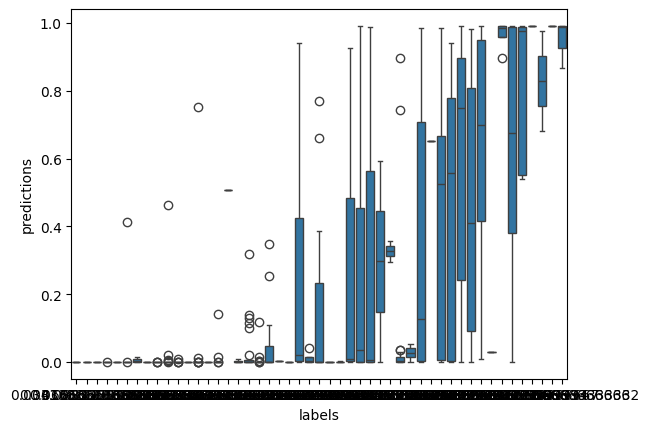

In [111]:
sns.boxplot(data=label_predictions, x='labels', y='predictions')

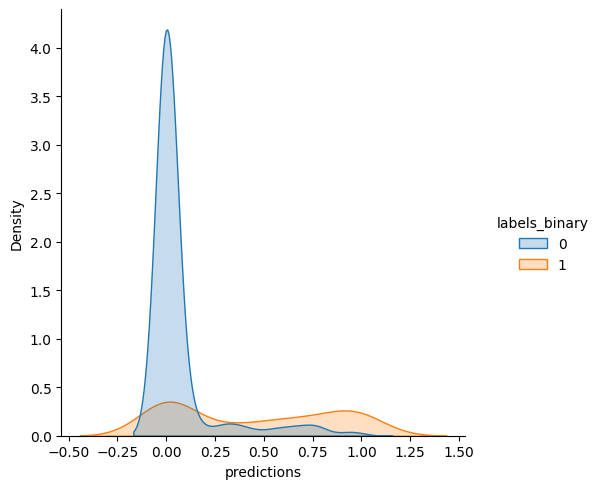

In [112]:
label_predictions['labels_binary'] = label_predictions['labels'].apply(lambda x: 1 if x > 0.5 else 0)
sns.displot(label_predictions, x='predictions', hue='labels_binary', kind='kde', fill=True)

### balanced valid set

In [ ]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-with-gpt2-large-embeds/step_1116_best_checkpoint/labels_predictions.csv', index_col=0)

In [ ]:
label_predictions['labels_bins'] = label_predictions['labels'].apply(bin_labels)

In [ ]:
balanced_label_predictions = label_predictions.loc[label_predictions['labels_bins'] < 9,:].groupby('labels_bins').sample(13,random_state=999)#.drop_duplicates()
balanced_label_predictions = pd.concat([balanced_label_predictions, label_predictions.loc[label_predictions['labels_bins'] == 9,:]])
print(balanced_label_predictions.shape)

(123, 3)


In [ ]:
balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.000125
0.20    0.000127
0.25    0.000129
0.30    0.000132
0.40    0.000143
0.50    0.001439
0.60    0.032399
0.70    0.438131
0.75    0.596801
0.80    0.729961
0.90    0.979568
1.00    0.991355
Name: predictions, dtype: float64

In [ ]:
print(f"acc: {accuracy_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions']):.4f}")


acc: 0.7642
auroc: 0.8725


### informality threshold

In [46]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-with-gpt2-large-embeds/step_1116_best_checkpoint/labels_predictions.csv', index_col=0)

In [47]:
label_predictions['labels_bins'] = label_predictions['labels'].apply(bin_labels)

In [48]:
balanced_label_predictions = label_predictions.loc[label_predictions['labels_bins'] < 9,:].groupby('labels_bins').sample(13,random_state=999)#.drop_duplicates()
balanced_label_predictions = pd.concat([balanced_label_predictions, label_predictions.loc[label_predictions['labels_bins'] == 9,:]])
print(balanced_label_predictions.shape)

(123, 3)


In [49]:
balanced_label_predictions['predictions'] = 1 - balanced_label_predictions['predictions']

In [50]:
balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.020432
0.20    0.270039
0.25    0.403199
0.30    0.561869
0.40    0.967601
0.50    0.998561
0.60    0.999857
0.70    0.999868
0.75    0.999871
0.80    0.999873
0.90    0.999875
1.00    0.999880
Name: predictions, dtype: float64

## sentiment, energy

In [90]:
# sentiment, energy model
args = argparse.Namespace(
    checkpoint_dir='/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-energy-training/step_81900_best_checkpoint',
    test_data_path='/data/hyeryung/loc_edit/data/yelp/valid.jsonl',
    test_data_type='jsonl',
    output_dir='/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-energy-training/step_81900_best_checkpoint',
    batch_size=32,
    model_type='roberta-base'
)

label_predictions = predict_labels(args,device)
if label_predictions['labels'].max() > 1:
    label_predictions['labels'] = label_predictions['labels'].apply(lambda x: (x - 1.)/4. )
print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")


0.10    0.002777
0.20    0.174225
0.25    0.390087
0.30    0.573905
0.40    0.887451
0.50    0.965995
0.60    0.991556
0.70    0.998068
0.75    0.999145
0.80    0.999699
0.90    0.999976
1.00    0.999999
Name: predictions, dtype: float64
acc: 0.9464
auroc: 0.9892


In [97]:
print(f"Proportion of label 0: {(label_predictions['labels'] <= 0.5).sum() / len(label_predictions['labels'])}")
print(label_predictions['predictions'].quantile(0.33))

Proportion of label 0: 0.3298
0.7386573630571366


In [ ]:
prop_75 = (label_predictions['labels'] <= 0.75).sum() / len(label_predictions['labels'])
print(f"Proportion of label 0: {prop_75}")
print(label_predictions['predictions'].quantile(prop_75))

Proportion of label 0: 0.9255533199195171
0.849987830194669


### plots

Text(0.5, 1.0, 'Energy Model Predictions Sorted by Value (sentiment)')

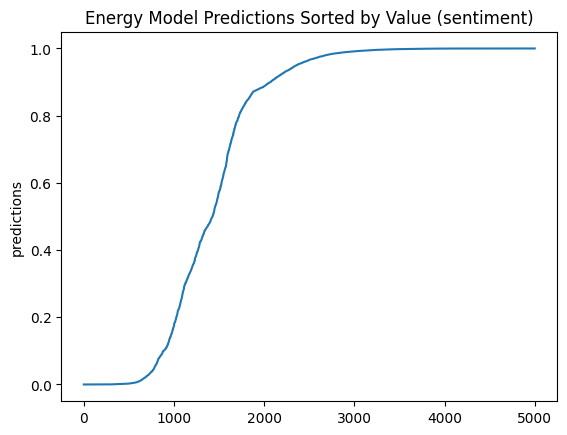

In [ ]:
sorted_vals = label_predictions['predictions'].sort_values()
sns.lineplot(data = None, x= range(len(sorted_vals)), y =sorted_vals)
plt.title('Energy Model Predictions Sorted by Value (sentiment)')

<Axes: xlabel='labels', ylabel='predictions'>

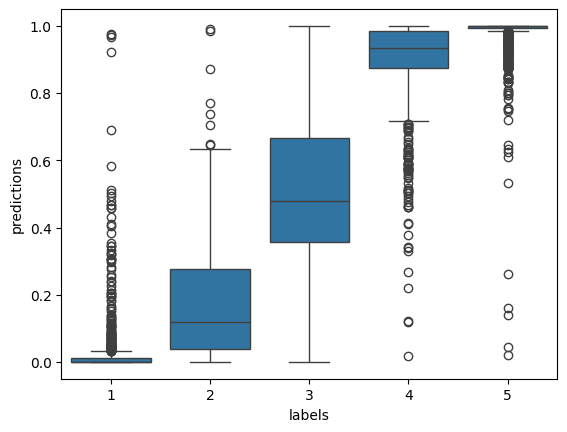

In [ ]:
sns.boxplot(data=label_predictions, x='labels', y='predictions')

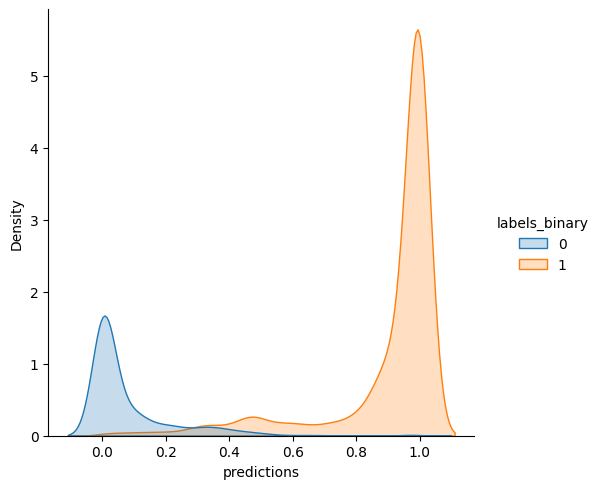

In [ ]:
label_predictions['labels_binary'] = label_predictions['labels'].apply(lambda x: 1 if x > 0.5 else 0)
sns.displot(label_predictions, x='predictions', hue='labels_binary', kind='kde', fill=True)

### balanced valid set

In [195]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-energy-training/step_81900_best_checkpoint/labels_predictions.csv', index_col=0)

In [196]:
label_predictions['labels'] = label_predictions['labels'].apply(lambda x: (x - 1.)/4. )

In [169]:
label_predictions['labels'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.00
0.20    0.25
0.25    0.50
0.30    0.50
0.40    0.75
0.50    0.75
0.60    1.00
0.70    1.00
0.75    1.00
0.80    1.00
0.90    1.00
1.00    1.00
Name: labels, dtype: float64

In [197]:
label_predictions['labels_bins'] = label_predictions['labels']#.apply(bin_labels)

In [171]:
label_predictions['labels_bins'].value_counts().sort_index()

labels_bins
0.00     765
0.25     389
0.50     495
0.75    1039
1.00    2312
Name: count, dtype: int64

In [198]:
balanced_label_predictions = label_predictions.groupby('labels_bins').sample(389, random_state=999)#.drop_duplicates()
print(balanced_label_predictions.shape)

(1945, 3)


In [175]:
balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.001023
0.20    0.026121
0.25    0.078115
0.30    0.132620
0.40    0.328918
0.50    0.500150
0.60    0.809421
0.70    0.927162
0.75    0.970762
0.80    0.990170
0.90    0.999563
1.00    0.999999
Name: predictions, dtype: float64

In [199]:
print(f"acc: {accuracy_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions']):.4f}")


acc: 0.8936
auroc: 0.9834


### negativity threshold

In [34]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-energy-training/step_81900_best_checkpoint/labels_predictions.csv', index_col=0)

In [35]:
label_predictions['labels_bins'] = label_predictions['labels']#.apply(bin_labels)

In [36]:
label_predictions['labels_bins'].value_counts().sort_index()

labels_bins
1     765
2     389
3     495
4    1039
5    2312
Name: count, dtype: int64

In [37]:
balanced_label_predictions = label_predictions.groupby('labels_bins').sample(389, random_state=999)#.drop_duplicates()
print(balanced_label_predictions.shape)

(1945, 3)


In [38]:
balanced_label_predictions['predictions'] = 1- balanced_label_predictions['predictions']

In [39]:
balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.000437
0.20    0.009830
0.25    0.029238
0.30    0.072838
0.40    0.190579
0.50    0.499850
0.60    0.671082
0.70    0.867380
0.75    0.921885
0.80    0.973879
0.90    0.998977
1.00    0.999998
Name: predictions, dtype: float64

## sentiment, classifier

In [ ]:
# sentiment, classifier model
args = argparse.Namespace(
    checkpoint_dir='/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-with-gpt2-large-embeds/step_114500_best_checkpoint',
    test_data_path='/data/hyeryung/loc_edit/data/yelp/valid.jsonl',
    test_data_type='jsonl',
    output_dir='/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-with-gpt2-large-embeds/step_114500_best_checkpoint',
    batch_size=32,
    model_type='roberta-base-custom'
)

label_predictions = predict_labels(args,device)
if label_predictions['labels'].max() > 1:
    label_predictions['labels'] = label_predictions['labels'].apply(lambda x: (x - 1.)/4. )
print(label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0]))
print(f"acc: {accuracy_score(label_predictions['labels']>0.5, label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(label_predictions['labels']>0.5, label_predictions['predictions']):.4f}")


50265
0.10    8.622667e-07
0.20    1.429650e-04
0.25    1.669537e-02
0.30    9.381881e-01
0.40    9.999993e-01
0.50    1.000000e+00
0.60    1.000000e+00
0.70    1.000000e+00
0.75    1.000000e+00
0.80    1.000000e+00
0.90    1.000000e+00
1.00    1.000000e+00
Name: predictions, dtype: float64
acc: 0.9420
auroc: 0.9815


In [99]:
print(f"Proportion of label 0: {(label_predictions['labels'] <= 0.5).sum() / len(label_predictions['labels'])}")
print(label_predictions['predictions'].quantile(0.33))

Proportion of label 0: 0.3298
0.9992624485492706


In [ ]:
label_predictions.groupby('labels').size().cumsum()

labels
1     765
2     389
3     495
4    1039
5    2312
dtype: int64

### plots

<Axes: xlabel='labels', ylabel='predictions'>

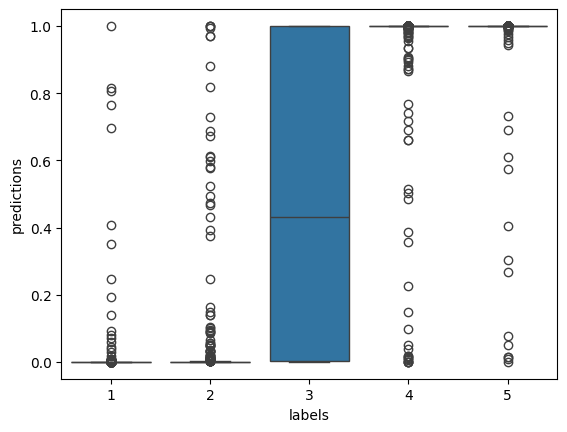

In [68]:
sns.boxplot(data=label_predictions, x='labels', y='predictions')

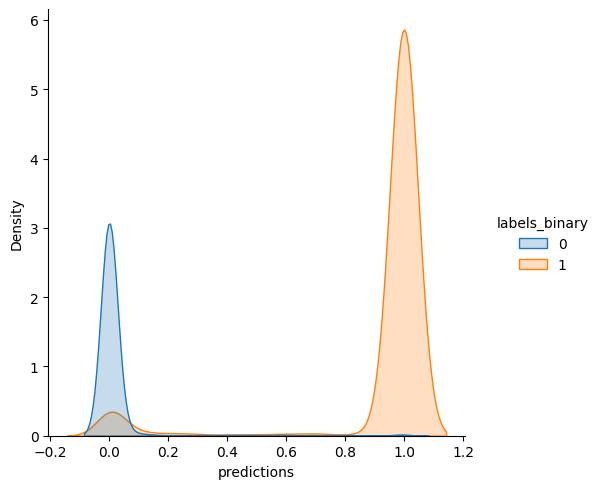

In [ ]:
label_predictions['labels_binary'] = label_predictions['labels'].apply(lambda x: 1 if x > 0.5 else 0)
sns.displot(label_predictions, x='predictions', hue='labels_binary', kind='kde', fill=True)

Text(0.5, 1.0, 'Classifier Model Predictions Sorted by Value (sentiment)')

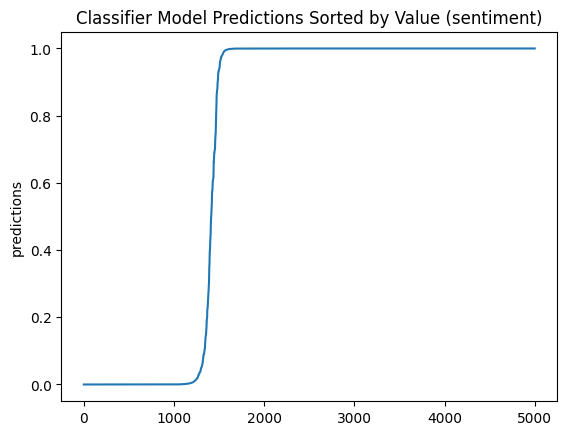

In [84]:
sorted_vals = label_predictions['predictions'].sort_values()
sns.lineplot(data = None, x= range(len(sorted_vals)), y =sorted_vals)
plt.title('Classifier Model Predictions Sorted by Value (sentiment)')

### balanced valid set

In [200]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-with-gpt2-large-embeds/step_114500_best_checkpoint/labels_predictions.csv', index_col=0)

In [201]:
label_predictions['labels'] = label_predictions['labels'].apply(lambda x: (x - 1.)/4. )

In [202]:
label_predictions['labels'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.00
0.20    0.25
0.25    0.50
0.30    0.50
0.40    0.75
0.50    0.75
0.60    1.00
0.70    1.00
0.75    1.00
0.80    1.00
0.90    1.00
1.00    1.00
Name: labels, dtype: float64

In [203]:
label_predictions['labels_bins'] = label_predictions['labels']#.apply(bin_labels)

In [204]:
label_predictions['labels_bins'].value_counts().sort_index()

labels_bins
0.00     765
0.25     389
0.50     495
0.75    1039
1.00    2312
Name: count, dtype: int64

In [205]:
balanced_label_predictions = label_predictions.groupby('labels_bins').sample(389, random_state=999)#.drop_duplicates()
print(balanced_label_predictions.shape)

(1945, 3)


In [206]:
balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    3.340028e-07
0.20    2.043536e-06
0.25    6.287420e-06
0.30    4.745365e-05
0.40    2.911271e-03
0.50    6.076121e-01
0.60    9.999562e-01
0.70    1.000000e+00
0.75    1.000000e+00
0.80    1.000000e+00
0.90    1.000000e+00
1.00    1.000000e+00
Name: predictions, dtype: float64

In [207]:
print(f"acc: {accuracy_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions'] > 0.5):.4f}")
print(f"auroc: {roc_auc_score(balanced_label_predictions['labels']>0.5, balanced_label_predictions['predictions']):.4f}")


acc: 0.8859
auroc: 0.9766


### negativity threshold

In [40]:
label_predictions = pd.read_csv('/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-with-gpt2-large-embeds/step_114500_best_checkpoint/labels_predictions.csv', index_col=0)

In [41]:
label_predictions['labels_bins'] = label_predictions['labels']#.apply(bin_labels)

In [42]:
label_predictions['labels_bins'].value_counts().sort_index()

labels_bins
1     765
2     389
3     495
4    1039
5    2312
Name: count, dtype: int64

In [43]:
balanced_label_predictions = label_predictions.groupby('labels_bins').sample(389, random_state=999)#.drop_duplicates()
print(balanced_label_predictions.shape)

(1945, 3)


In [44]:
balanced_label_predictions['predictions'] = 1- balanced_label_predictions['predictions']

In [45]:
balanced_label_predictions['predictions'].quantile([0.1, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 1.0])

0.10    0.000000
0.20    0.000000
0.25    0.000000
0.30    0.000000
0.40    0.000044
0.50    0.392388
0.60    0.997089
0.70    0.999953
0.75    0.999994
0.80    0.999998
0.90    1.000000
1.00    1.000000
Name: predictions, dtype: float64

# Check portion of test data after applying the thresholds

In [ ]:
def get_allsats_and_losses(config):
    resume_idx=0
    text_id_interval=1
    loss_weights = config['loss_weights']


    ## taken from new_mlm_reranking_all.py
    if (config["task"] == "toxicity") or (config["task"] == "sentiment"):
        source_dataset = [
            json.loads(l)[config["jsonl_primary_key"]][config["jsonl_secondary_key"]]
            for l in open(config["source_data"])
        ]
        generation_dataset = [
            json.loads(l)["generations"] for l in open(config["source_data"])
        ]
    elif (config["task"] == "formality") or (config["task"] == "sentiment-lewis-compr"):
        with open(config["source_data"], "r") as f:
            generation_dataset = [line.rstrip('\n') for line in f.readlines()]
        source_dataset = ["" for l in generation_dataset]
        
    elif (config["task"] == "nli"):
        generation_dataset = [
            (json.loads(l)["sentence1"],json.loads(l)["sentence2"]) for l in open(config["source_data"]) if (json.loads(l)["gold_label"] == "contradiction") 
        ]
        source_dataset = ["" for l in generation_dataset]

    name2tokenizer = {}
    name2model = {}
    name2config = {}
    loss2tokenizer = {}
    for i, model_path in enumerate(config["model_paths"]):
        if (
            model_path not in name2model
        ):  # making sure we are not loading the model twice in case some constraints use the same model.
            try:
                name2tokenizer[config["tokenizer_paths"][i]] = AutoTokenizer.from_pretrained(
                    config["tokenizer_paths"][i],
                    cache_dir=config["cache_dir"],
                    use_fast=True,
                )
            except:
                name2tokenizer[config["tokenizer_paths"][i]] = AutoTokenizer.from_pretrained(
                    config["tokenizer_paths"][i],
                    cache_dir=config["cache_dir"],
                    use_fast=False,
                )

            name2config[model_path] = AutoConfig.from_pretrained(
                model_path, cache_dir=config["cache_dir"]
            )

            if config["model_types"][i] == "RobertaCustomForSequenceClassification":
                name2model[model_path] = lossbuilder.ModelWrapper(
                    RobertaCustomForSequenceClassification.from_pretrained(
                        model_path,
                        config=name2config[model_path],
                        cache_dir=config["cache_dir"],
                    )
                )
            else:
                name2model[model_path] = lossbuilder.ModelWrapper(
                    getattr(transformers, config["model_types"][i]).from_pretrained(
                        model_path,
                        config=name2config[model_path],
                        cache_dir=config["cache_dir"],
                    )
                )
            name2model[model_path].eval()
            name2model[model_path].to(config['device'])

    class dummyArgs:
        def __init__(self, **kwargs):
            for k, v in kwargs.items():
                setattr(self, k, v)

    build_loss_dict = json.loads('{"coeff_steps": 200, "coeff_pattern": "constant", "loss_type": "xentropy", "length_normalize": false, "AR_temperature": 1.0, "AR_top_k": 0, "AR_top_p": 0.96, "max_output_length": 20}')
    build_loss_args = dummyArgs(**build_loss_dict)
    build_loss_args.task = config["task"]
    lossfns = []
    for i, loss in enumerate(config["losses"]):
        lossfns.append(
            lossbuilder.build_loss(
                loss,
                name2model[config["model_paths"][i]],
                name2tokenizer[config["tokenizer_paths"][i]],
                build_loss_args,
            )
        )
        # lossfns[i].tokenizer.add_special_tokens({"mask_token": mlm_tokenizer.mask_token})
        loss2tokenizer[loss] = lossfns[i].tokenizer

    allsats = []
    losses = []
    for text_id in range(resume_idx, len(source_dataset), text_id_interval):
        source_text = source_dataset[text_id]
        if source_text == "":
            source_text = lossfns[0].tokenizer.bos_token

        if (config["task"] == "toxicity") or (config["task"] == "sentiment"):
            AR_prediction_all = [x["text"] for x in generation_dataset[text_id]]
            
        elif (config["task"] == "formality") or (
            config["task"] == "sentiment-lewis-compr"
        ) or (config["task"] == "nli"):
            AR_prediction_all = generation_dataset[text_id: text_id + text_id_interval]

        curr_num_samples = len(AR_prediction_all)
        curr_loss = torch.zeros(len(AR_prediction_all)).to(config['device'])
        logging_loss = torch.zeros((len(AR_prediction_all),len(config["losses"]))).to(config['device'])
        edit_yn = torch.ones(len(AR_prediction_all), dtype=torch.bool).to(config['device'])

        for lossid, lossname in enumerate(config["losses"]):
            with torch.no_grad():
                lossvalue = lossfns[lossid].compute_gold_loss(
                    source_text, AR_prediction_all,
                    label_id=config['target_label_ids'][lossid],
                )
                torch.cuda.empty_cache()
            curr_loss += loss_weights[lossid] * lossvalue
            logging_loss[:, lossid] = lossvalue.clone()


        allsat = logging_loss[:,-1] < -math.log(config["min_epsilons"][0])
        allsats.extend(allsat.cpu().tolist())
        losses.extend(logging_loss[:,-1].cpu().tolist())
    return allsats, losses
    

In [37]:
config = {'task': 'toxicity',
          'source_data': '/data/hyeryung/mucoco/new_module/data/toxicity-avoidance/testset_gpt2_2500.jsonl',
          'model_paths': ['/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-energy-training/step_1000_best_checkpoint'],
          'model_types': ['AutoModelForSequenceClassification'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [0.79],
          'target_label_ids': [0],
          'losses': ["classification_no_prefix_logprobloss"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats, losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")

468 out of 2500 samples are not satisfied


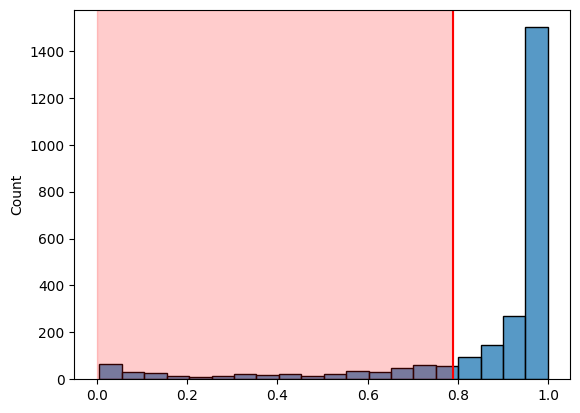

In [38]:
# -logp to p 
probas = np.exp(-1*np.array(losses))
sns.histplot(probas, bins=20)
plt.axvline(config['min_epsilons'],color='red')
plt.axvspan(0, config['min_epsilons'][0],color='red',alpha=0.2)

In [35]:
# formality, informal to formal
config = {'task': 'formality',
          'source_data': '/data/hyeryung/mucoco/data/formality/GYAFC_Corpus/Entertainment_Music/test/informal',
          'model_paths': ['/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-energy-training/step_1120_best_checkpoint/'],
          'model_types': ['AutoModelForSequenceClassification'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [0.74],
          'target_label_ids': [1],
          'losses': ["classification_no_prefix_logprobloss"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats,losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")

1416 out of 1416 samples are not satisfied


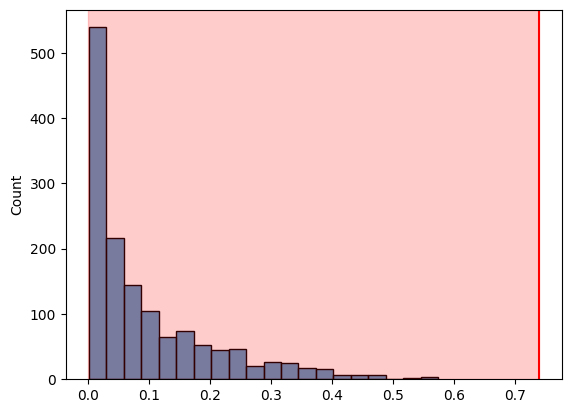

In [36]:
# -logp to p 
probas = np.exp(-1*np.array(losses))
sns.histplot(probas, bins=20)
plt.axvline(config['min_epsilons'],color='red')
plt.axvspan(0, config['min_epsilons'][0],color='red',alpha=0.2)

In [23]:
# formality, formal to informal
config = {'task': 'formality',
          'source_data': '/data/hyeryung/mucoco/data/formality/GYAFC_Corpus/Entertainment_Music/test/formal',
          'model_paths': ['/data/hyeryung/loc_edit/models/roberta-base-pt16-formality-classifier-energy-training/step_1120_best_checkpoint/'],
          'model_types': ['AutoModelForSequenceClassification'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [0.88],
          'target_label_ids': [0],
          'losses': ["classification_no_prefix_logprobloss"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats,losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")

1052 out of 1082 samples are not satisfied


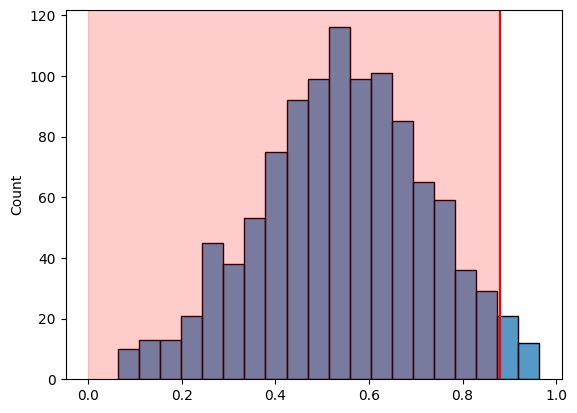

In [28]:
# -logp to p 
probas = np.exp(-1*np.array(losses))
sns.histplot(probas)
plt.axvline(config['min_epsilons'],color='red')
plt.axvspan(0, config['min_epsilons'][0],color='red',alpha=0.2)

In [30]:
# sentiment, positive
config = {'task': 'sentiment',
          'source_data': '/data/hyeryung/mucoco/new_module/data/sentiment/dev_set.jsonl',
          'model_paths': ['/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-energy-training/step_81900_best_checkpoint'],
          'model_types': ['AutoModelForSequenceClassification'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [0.97],
          'target_label_ids': [1],
          'losses': ["classification_no_prefix_logprobloss"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats,losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")

778 out of 900 samples are not satisfied


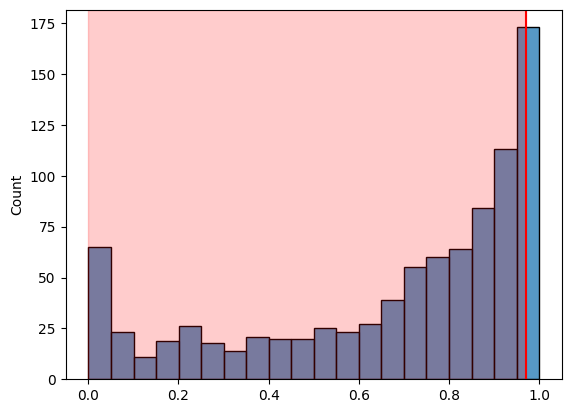

In [32]:
# -logp to p 
probas = np.exp(-1*np.array(losses))
sns.histplot(probas, bins=20)
plt.axvline(config['min_epsilons'],color='red')
plt.axvspan(0, config['min_epsilons'][0],color='red',alpha=0.2)

In [33]:
# sentiment, negative
config = {'task': 'sentiment',
          'source_data': '/data/hyeryung/mucoco/new_module/data/sentiment/dev_set.jsonl',
          'model_paths': ['/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-energy-training/step_81900_best_checkpoint'],
          'model_types': ['AutoModelForSequenceClassification'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [0.92],
          'target_label_ids': [0],
          'losses': ["classification_no_prefix_logprobloss"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats,losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")

827 out of 900 samples are not satisfied


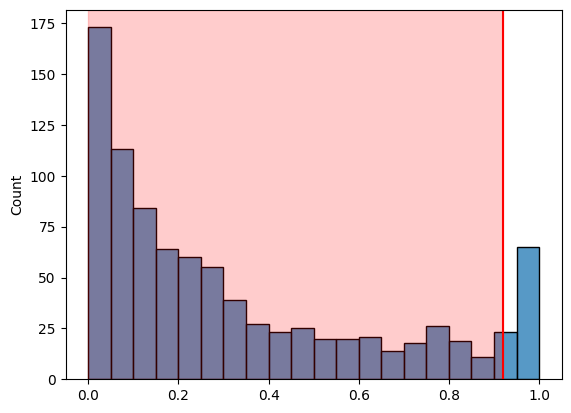

In [34]:
# -logp to p 
probas = np.exp(-1*np.array(losses))
sns.histplot(probas, bins=20)
plt.axvline(config['min_epsilons'],color='red')
plt.axvspan(0, config['min_epsilons'][0],color='red',alpha=0.2)

# Save below-threshold test set

## toxicity, nontoxic

In [94]:
config = {'task': 'toxicity',
          'source_data': '/data/hyeryung/mucoco/new_module/data/toxicity-avoidance/testset_gpt2_2500.jsonl',
          'model_paths': ['/data/hyeryung/loc_edit/models/roberta-base-jigsaw-toxicity-classifier-energy-training/step_1000_best_checkpoint'],
          'model_types': ['AutoModelForSequenceClassification'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [0.79],
          'target_label_ids': [0],
          'losses': ["classification_no_prefix_logprobloss"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats, losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")

468 out of 2500 samples are not satisfied


In [95]:
# save index
nonsat_index = np.where(~np.array(allsats))[0].tolist()
with open('/data/hyeryung/mucoco/new_module/data/toxicity-avoidance/testset_gpt2_2500_below_nontoxic_threshold_index.txt', 'w') as f:
    f.writelines(' '.join([str(x) for x in nonsat_index]))
    f.write('\n')

In [ ]:
# read source data
data = pd.read_json(config['source_data'], lines=True)
# unravel
data = data.explode('generations').reset_index().rename(columns={'index':'prompt_idx'})
# select those below threshold
data = data.loc[~np.array(allsats),:].copy()
# ravel back data
data['generations'] = data['generations'].apply(lambda x: [x])
generations = data.groupby('prompt_idx')['generations'].sum().reset_index()
prompts = data[['prompt_idx','prompt']].drop_duplicates(subset='prompt_idx')
filtered_data = pd.merge(prompts, generations, on='prompt_idx')
filtered_data = filtered_data.sort_values(by='prompt_idx').drop(columns='prompt_idx')
# save data
filtered_data.to_json('/data/hyeryung/mucoco/new_module/data/toxicity-avoidance/testset_gpt2_2500_below_nontoxic_threshold_468.jsonl', orient='records', lines=True)

## sentiment, positive

In [96]:
# sentiment, positive
config = {'task': 'sentiment',
          'source_data': '/data/hyeryung/mucoco/new_module/data/sentiment/dev_set.jsonl',
          'model_paths': ['/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-energy-training/step_81900_best_checkpoint'],
          'model_types': ['AutoModelForSequenceClassification'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [0.97],
          'target_label_ids': [1],
          'losses': ["classification_no_prefix_logprobloss"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats,losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")

778 out of 900 samples are not satisfied


In [97]:
# save index
nonsat_index = np.where(~np.array(allsats))[0].tolist()
print(len(nonsat_index))
with open('/data/hyeryung/mucoco/new_module/data/sentiment/dev_set_below_positive_threshold_index.jsonl', 'w') as f:
    f.writelines(' '.join([str(x) for x in nonsat_index]))
    f.write('\n')

778


In [71]:
# read source data
data = pd.read_json(config['source_data'], lines=True)

# unravel
data = data.explode('generations').reset_index().rename(columns={'index':'prompt_idx'})

# select those below threshold
data = data.loc[~np.array(allsats),:].copy()
print(data.shape)

# ravel back data
data['generations'] = data['generations'].apply(lambda x: [x])
generations = data.groupby('prompt_idx')['generations'].sum().reset_index()
prompts = data[['prompt_idx','prompt']].drop_duplicates(subset='prompt_idx')
filtered_data = pd.merge(prompts, generations, on='prompt_idx')
filtered_data = filtered_data.sort_values(by='prompt_idx').drop(columns='prompt_idx')

# save data
filtered_data.to_json('/data/hyeryung/mucoco/new_module/data/sentiment/dev_set_below_positive_threshold_778.jsonl', orient='records', lines=True)

(778, 4)


## sentiment, negative

In [98]:
# sentiment, negative
config = {'task': 'sentiment',
          'source_data': '/data/hyeryung/mucoco/new_module/data/sentiment/dev_set.jsonl',
          'model_paths': ['/data/hyeryung/loc_edit/models/roberta-base-yelp-sentiment-classifier-energy-training/step_81900_best_checkpoint'],
          'model_types': ['AutoModelForSequenceClassification'],
          'jsonl_primary_key': 'prompt',
          'jsonl_secondary_key': 'text',
          'loss_weights': [1.0],
          'min_epsilons': [0.92],
          'target_label_ids': [0],
          'losses': ["classification_no_prefix_logprobloss"],
          'device': 'cuda'}
config['tokenizer_paths']=config['model_paths']
config['cache_dir'] ='/data/hyeryung/hf_cache'

allsats,losses = get_allsats_and_losses(config)
print(f"{sum(~np.array(allsats))} out of {len(allsats)} samples are not satisfied")

827 out of 900 samples are not satisfied


In [99]:
# save index
nonsat_index = np.where(~np.array(allsats))[0].tolist()
print(len(nonsat_index))
with open('/data/hyeryung/mucoco/new_module/data/sentiment/dev_set_below_negative_threshold_index.jsonl', 'w') as f:
    f.writelines(' '.join([str(x) for x in nonsat_index]))
    f.write('\n')

827


In [73]:
# read source data
data = pd.read_json(config['source_data'], lines=True)

# unravel
data = data.explode('generations').reset_index().rename(columns={'index':'prompt_idx'})

# select those below threshold
data = data.loc[~np.array(allsats),:].copy()
print(data.shape)

# ravel back data
data['generations'] = data['generations'].apply(lambda x: [x])
generations = data.groupby('prompt_idx')['generations'].sum().reset_index()
prompts = data[['prompt_idx','prompt']].drop_duplicates(subset='prompt_idx')
filtered_data = pd.merge(prompts, generations, on='prompt_idx')
filtered_data = filtered_data.sort_values(by='prompt_idx').drop(columns='prompt_idx')

# save data
filtered_data.to_json('/data/hyeryung/mucoco/new_module/data/sentiment/dev_set_below_negative_threshold_827.jsonl', orient='records', lines=True)

(827, 4)
